# LFM Segmentation Example Workflow
This notebook is an example workflow of doing binary segmentation on visual light (RGB) bands of Lunar data. 

You can get started with this notebook by downloading it with:

```bash
wget https://raw.githubusercontent.com/nasa-nccs-hpda/lfm/refs/heads/main/notebooks/finetune_dinov3.ipynb
```

**See the README in the [repo](https://github.com/nasa-nccs-hpda/lfm)** for more info on how to use this notebook, and more on the process of training the model. 

## Imports, Dino Repo Clone

In [1]:
import os
import sys
import torch
import subprocess
from glob import glob

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

%matplotlib inline

In [2]:
repo_dir = "lfm"

if not os.path.exists(repo_dir):
    subprocess.run(["git", "clone", f"https://github.com/nasa-nccs-hpda/{repo_dir}"])
# else:
#     subprocess.run(["git", "-C", repo_dir, "pull"])
subprocess.run(["git", "-C", repo_dir, "checkout", "develop"])
subprocess.run(["git", "-C", repo_dir, "pull"])

Already on 'develop'


Your branch is up to date with 'origin/develop'.
Updating 271a08a..d904b31
Fast-forward
 lfm/tasks/inst_segmentation/driver.py    | 616 +++++++++++++++++++------------
 notebooks/finetune_dinov3_inst_seg.ipynb | 465 ++++++++++++++++++++++-
 2 files changed, 826 insertions(+), 255 deletions(-)


From https://github.com/nasa-nccs-hpda/lfm
   271a08a..d904b31  develop    -> origin/develop


CompletedProcess(args=['git', '-C', 'lfm', 'pull'], returncode=0)

In [3]:
sys.path.append("lfm")

from lfm.tasks.inst_segmentation.model import DINOInstanceSegmentation, load_dinov3_encoder
from lfm.tasks.inst_segmentation.dataset import get_dataloaders
from lfm.tasks.inst_segmentation.driver import train_model
from lfm.tasks.inst_segmentation.mask2former_model import create_mask2former_dinov3_model
# from lfm.tasks.segmentation.utils import install_termcolor_locally

### Install termcolor package (required by DinoV3)

In [4]:
# install_termcolor_locally()

## Main workflow

1. Define user-configured variables
2. Create dataloaders from files on /explore/nobackup/.
3. Load DinoV3 encoder, create encoder/decoder finetuning model.
4. Train model, print training stats, and visualize results. 

### User Config

In [5]:
# Weights URL (received after registering for DINOV3)
weights_URL = (
    "https://dinov3.llamameta.net/dinov3_vitl16/"
    "dinov3_vitl16_pretrain_sat493m-eadcf0ff.pth"
    "?Policy=eyJTdGF0ZW1lbnQiOlt7InVuaXF1ZV9oYXNoIjoiNDloYXZtdThkZGh3eGw3aH"
    "JwNjQwa3E3IiwiUmVzb3VyY2UiOiJodHRwczpcL1wvZGlub3YzLmxsYW1hbWV0YS5uZXR"
    "cLyoiLCJDb25kaXRpb24iOnsiRGF0ZUxlc3NUaGFuIjp7IkFXUzpFcG9jaFRpbWUiOjE"
    "3Njc5OTI2Njl9fX1dfQ__"
    "&Signature=neHREO7xc90azhmnF3r9qPztYJ5L2wO-EZkVKh6ECzR5H2YGzdK3dcF"
    "WQISNb6xYo3R5EO39FKJ7bwELXA%7EgoBqDbk-jm-9n9%7EVxtEOmWVx73usrILMwhyi"
    "cP5-448rbnUzOEM0lPkGS829mOBJkaSxxSsbkQ0VpVBcScNEFcpaNOZ--BeHxCHdTFV"
    "NGkhlEaCYPUbYyHYbTgDQntH2AsKYJTWw4NIEZJZLX9wjCOYKQ-YG86d0HJAvsdF79X"
    "vITPgJSA0U-4Z1CzIkQhZb0N-7-XnbZmnJJi42xnNS0DsB6CTedxq0FAfiYklBY77wT"
    "JrYLba%7Epkap23ymoUTxDXA__"
    "&Key-Pair-Id=K15QRJLYKIFSLZ"
    "&Download-Request-ID=1618342689192585"
)
weights_local_checkpoint = '/explore/nobackup/projects/ilab/models/dinov3/dinov3_vitl16_pretrain_sat493m-eadcf0ff.pth'

# Data paths
INPUT_DIR = "/explore/nobackup/projects/lfm/inst_seg_viz_chips_3_band"
IMAGE_DIR = f"{INPUT_DIR}/chips"
LABEL_DIR = f"{INPUT_DIR}/labels_npy"

# Output dir (this will be created automatically)
OUTPUT_DIR = "./outputs"  # Change this if you want a specific path
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")

# Location of cloned dinov3 repo
REPO_DIR = "./dinov3"

# Dataset parameters
MAX_SAMPLES = 500  # Set to None to use all available samples, or an integer to limit
TRAIN_SPLIT = 0.8  # 80% train, 20% validation

# Training hyperparameters
BATCH_SIZE = 16
NUM_EPOCHS = 10  # 10 is the default value, change to more epochs for more model learning
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 4
LOSS_TYPE = "instance_combined"  # Combined Dice + Binary CE loss

# Model parameters
TARGET_SIZE = (304, 304)  # Input size for DINO model
FREEZE_ENCODER = False

# Visualization and saving
CHECKPOINT_EVERY = 10  # Save checkpoint every N epochs
VISUALIZE_EVERY = 10  # Create visualizations every N epochs

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Output directory: ./outputs
Using device: cuda


### Create dataloaders

In [6]:
# ============================================================================
# CREATE DATALOADERS
# ============================================================================

print("\n" + "="*60)
print("STEP 1: Creating dataloaders.")
print("="*60)

train_loader, val_loader, MEAN, STD = get_dataloaders(
    image_dir=IMAGE_DIR,
    label_dir=LABEL_DIR,
    batch_size=BATCH_SIZE,
    train_split=TRAIN_SPLIT,
    num_workers=NUM_WORKERS,
    target_size=TARGET_SIZE,
    max_samples=MAX_SAMPLES,
    seed=42,
    stats_save_dir=OUTPUT_DIR
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")


STEP 1: Creating dataloaders.
Loading existing dataset statistics...
Mean per channel: [0.32744208 0.32249309 0.302985  ]
Std per channel: [0.15045737 0.15014801 0.14386101]
Limited to 500 samples
Found 500 matched image-label pairs
Dataset configured for 3 channel(s)
Train samples: 400
Val samples: 100
Train batches: 25
Val batches: 7


### Load Encoder and Create Model

In [ ]:
print("\n" + "="*60)
print("Loading mask2former Dino model...")
print("="*60)

model = create_mask2former_dinov3_model(
    label2id: Dict[str, int]={},  # TODO
    id2label: Dict[int, str]={},  # TODO
    dinov3_model_name='dinov3_vitl16',
    expected_channels: List[int] = [96, 192, 384, 768],
    freeze_backbone: bool = True,
    hub_token: str = None
)

### Run Training

In [9]:
print("\n" + "="*60)
print("Starting training.")
print("="*60)

train_losses, val_losses = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    mode="train",
    output_dir=OUTPUT_DIR,
    num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    checkpoint_every=CHECKPOINT_EVERY,
    visualize_every=VISUALIZE_EVERY,
    loss_type=LOSS_TYPE,
    device=device
)


Starting training.
Using device: cuda
Using loss function: instance_combined
Loss function: InstanceSegmentationLoss

Starting training for 10 epochs...
Starting from epoch: 1
Checkpoints will be saved every 10 epochs
Visualizations will be saved every 10 epochs

MODEL PARAMETER SUMMARY
Encoder:
  Trainable: 303,156,224 / 303,156,224 (100.00%)

Decoder:
  Trainable: 5,926,690 / 5,926,690 (100.00%)

Combined Model:
  Trainable: 309,082,914 / 309,082,914 (100.00%)


Epoch 1/10


Epoch 1/10 [Val]: 100%|██████████| 7/7 [00:06<00:00,  1.02it/s, loss=9.16]



Epoch 1 Summary:
  Train Loss: 7.0284
  Val Loss:   9.0143
  LR:         0.000098
  Time:       125.47s

  Train Loss Components:
    semantic       : 0.6848
    variance       : 0.0175
    distance       : 6.3253
    regularization : 0.8536

  Val Loss Components:
    semantic       : 0.6529
    variance       : 0.0000
    distance       : 8.3604
    regularization : 0.9917
Saved checkpoint to: ./outputs/checkpoints/best_model.pt

  ✅ Saved best model (val_loss: 9.0143)

Epoch 2/10


Epoch 2/10 [Val]: 100%|██████████| 7/7 [00:06<00:00,  1.02it/s, loss=5.92]



Epoch 2 Summary:
  Train Loss: 5.4892
  Val Loss:   5.4450
  LR:         0.000090
  Time:       127.91s

  Train Loss Components:
    semantic       : 0.6375
    variance       : 0.0044
    distance       : 4.8464
    regularization : 0.9421

  Val Loss Components:
    semantic       : 0.6211
    variance       : 0.0042
    distance       : 4.8187
    regularization : 0.9539
Saved checkpoint to: ./outputs/checkpoints/best_model.pt

  ✅ Saved best model (val_loss: 5.4450)

Epoch 3/10


...


Epoch 9 Summary:
  Train Loss: 3.9704
  Val Loss:   4.1525
  LR:         0.000002
  Time:       113.49s

  Train Loss Components:
    semantic       : 0.5495
    variance       : 0.0020
    distance       : 3.4179
    regularization : 0.9724

  Val Loss Components:
    semantic       : 0.5343
    variance       : 0.0020
    distance       : 3.6152
    regularization : 0.9726

Epoch 10/10


Epoch 10/10 [Val]: 100%|██████████| 7/7 [00:07<00:00,  1.01s/it, loss=4.03]



Epoch 10 Summary:
  Train Loss: 3.9541
  Val Loss:   4.1272
  LR:         0.000000
  Time:       112.69s

  Train Loss Components:
    semantic       : 0.5478
    variance       : 0.0020
    distance       : 3.4033
    regularization : 0.9729

  Val Loss Components:
    semantic       : 0.5304
    variance       : 0.0020
    distance       : 3.5939
    regularization : 0.9725
Saved checkpoint to: ./outputs/checkpoints/best_model.pt

  ✅ Saved best model (val_loss: 4.1272)
Saved checkpoint to: ./outputs/checkpoints/checkpoint_epoch_010.pt

  Generating visualizations...


Plotting predictions: 100%|██████████| 5/5 [00:00<00:00, 19.75it/s]


Saved visualization to ./outputs/visualizations/predictions_epoch_010.png
Average Semantic F1: 0.102
Average Instance F1: 0.000
Average Precision: 0.000
Average Recall: 0.000
Average IoU: 0.000

Training completed!
Best validation loss: 4.1272
Total training time: 1285.65s (21.43m)
Average time per epoch: 120.99s

Saved checkpoint to: ./outputs/checkpoints/final_model.pt
Saved final model to: ./outputs/checkpoints/final_model.pt

TRAINING SUMMARY
Final train loss: 3.9541
Final val loss: 4.1272
Best val loss: 4.1272
Total training time: 1285.65s (21.43m)
Average time per epoch: 120.99s

Outputs saved to: ./outputs
  - Checkpoints: ./outputs/checkpoints
  - Visualizations: ./outputs/visualizations


## Display some of the output visualizations

The training of the model is already producing some visualizations every N epochs.
Here we open some of the visualizations to look at them from the notebook.

In [10]:
visualization_dir = os.path.join(OUTPUT_DIR, 'visualizations')
visualization_filenames = sorted(glob(os.path.join(visualization_dir, '*.png')))

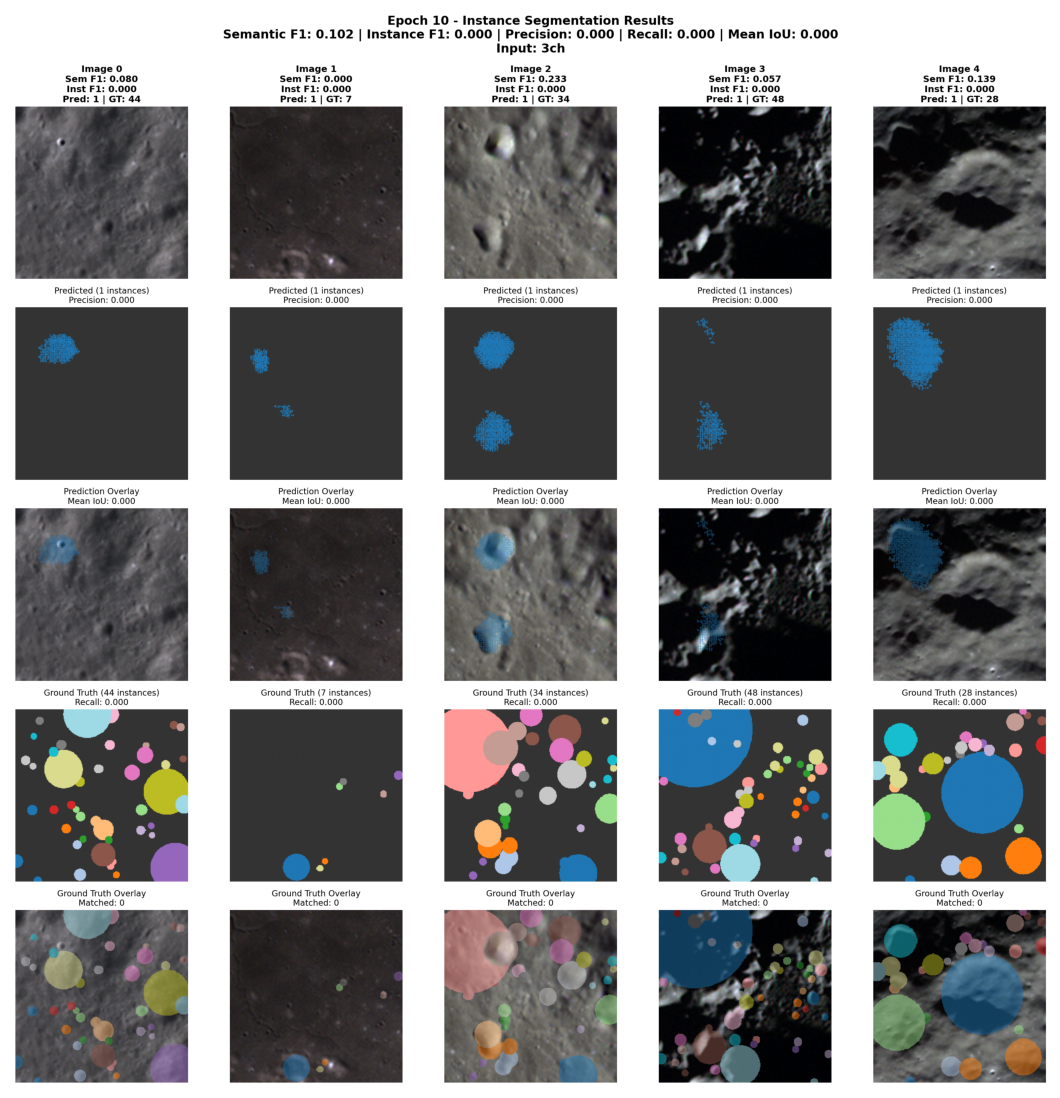

In [11]:
for vis_filename in visualization_filenames:

    img = mpimg.imread(vis_filename)
    
    plt.figure(figsize=(16, 14))
    plt.imshow(img)
    plt.axis("off")
    plt.show()